# COSC2671 — Assignment 2: Network Construction & Analysis
## What Makes a YouTube Gaming Video Go Viral?

This notebook builds and analyses two networks from the collected YouTube data:

1. **Co-Comment Network** (undirected, weighted)
   - Nodes = YouTube users (commenters)
   - Edges = two users commented on the same video
   - Weight = number of shared videos

2. **Reply Network** (directed, unweighted)
   - Nodes = YouTube users
   - Edges = user A replied to user B's comment

**Analysis performed:**
- Degree, betweenness, and eigenvector centrality
- PageRank (on reply network)
- Louvain community detection
- Network structure metrics (clustering, path length, degree distribution)
- Community-to-virality mapping

**Inputs:** `data/videos.csv`, `data/comments.csv`  
**Outputs:** `data/co_comment_graph.gexf`, `data/reply_graph.gexf`, `data/node_features.csv`

## Cell 1 — Install Dependencies

In [ ]:
# Run once
#!pip install networkx python-louvain pandas matplotlib seaborn scipy tqdm

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9473 sha256=d9124ae4a9ddd133bbd1849567f0555cbeeb2f861e32965a6f1b86b46a9bb528
  Stored in directory: c:\users\mitun\appdata\local\pip\cache\wheels\d0\b0\d7\6dd26c3817810fa379088eaeb755a01d9a2a411c37632079d1
Successfully built python-louvain


  DEPRECATION: Building 'python-louvain' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'python-louvain'. Discussion can be found at https://github.com/pypa/pip/issues/6334


## Cell 2 — Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain   # python-louvain package
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# ── Load data ─────────────────────────────────────────────────────────────────
videos_df = pd.read_csv('data/videos.csv')
comments_df = pd.read_csv('data/comments.csv')

# Drop rows with missing author IDs (anonymous comments)
comments_df = comments_df[comments_df['author_channel_id'].notna()]
comments_df = comments_df[comments_df['author_channel_id'] != '']

print(f"Videos loaded:   {len(videos_df):,}")
print(f"Comments loaded: {len(comments_df):,}")
print(f"Unique users:    {comments_df['author_channel_id'].nunique():,}")
print(f"Niches: {videos_df['niche'].unique().tolist()}")

# Build a video → virality tier lookup
video_tier = dict(zip(videos_df['video_id'], videos_df['virality_tier']))
video_niche = dict(zip(videos_df['video_id'], videos_df['niche']))

Videos loaded:   558
Comments loaded: 46,283
Unique users:    35,726
Niches: ['minecraft', 'valorant', 'gta6']


## Cell 3 — Build Co-Comment Network

In [3]:
print("Building co-comment network...")

# ── Group commenters by video ─────────────────────────────────────────────────
# Only use top-level comments (not replies) to avoid inflating edges
top_comments = comments_df[comments_df['is_reply'] == False]

video_to_users = top_comments.groupby('video_id')['author_channel_id'].apply(list).to_dict()

# ── Build edge list ───────────────────────────────────────────────────────────
# For each video, create edges between all pairs of commenters
# Edge weight = number of videos they co-commented on
edge_weights = defaultdict(int)

for video_id, users in tqdm(video_to_users.items(), desc="Building edges"):
    # Deduplicate users per video (a user may comment multiple times)
    unique_users = list(set(users))

    # Skip videos with too many commenters to avoid combinatorial explosion
    if len(unique_users) > 200:
        unique_users = unique_users[:200]

    for u, v in combinations(unique_users, 2):
        # Always use sorted tuple so (A,B) and (B,A) are the same edge
        key = tuple(sorted([u, v]))
        edge_weights[key] += 1

print(f"Raw edge count (before filtering): {len(edge_weights):,}")

# ── Filter edges ──────────────────────────────────────────────────────────────
# Keep only edges where users share at least 2 videos
# This removes noise from one-time coincidental co-comments
MIN_SHARED_VIDEOS = 2
filtered_edges = {k: v for k, v in edge_weights.items() if v >= MIN_SHARED_VIDEOS}
print(f"Filtered edge count (>={MIN_SHARED_VIDEOS} shared videos): {len(filtered_edges):,}")

# ── Construct NetworkX graph ──────────────────────────────────────────────────
G_co = nx.Graph()

for (u, v), weight in filtered_edges.items():
    G_co.add_edge(u, v, weight=weight)

print(f"\nCo-Comment Network:")
print(f"  Nodes: {G_co.number_of_nodes():,}")
print(f"  Edges: {G_co.number_of_edges():,}")
print(f"  Density: {nx.density(G_co):.6f}")
print(f"  Connected components: {nx.number_connected_components(G_co):,}")

# ── Keep only the largest connected component ─────────────────────────────────
# This is standard practice — isolated components don't contribute to analysis
lcc_nodes = max(nx.connected_components(G_co), key=len)
G_co = G_co.subgraph(lcc_nodes).copy()

print(f"\nLargest Connected Component (LCC):")
print(f"  Nodes: {G_co.number_of_nodes():,}")
print(f"  Edges: {G_co.number_of_edges():,}")

Building co-comment network...


Building edges: 100%|██████████| 555/555 [00:01<00:00, 477.52it/s]

Raw edge count (before filtering): 785,937
Filtered edge count (>=2 shared videos): 2,987

Co-Comment Network:
  Nodes: 1,030
  Edges: 2,987
  Density: 0.005637
  Connected components: 57

Largest Connected Component (LCC):
  Nodes: 377
  Edges: 1,218


## Cell 4 — Build Reply Network (Directed)

In [4]:
print("Building reply network...")

# ── Get reply-to relationships ────────────────────────────────────────────────
replies = comments_df[comments_df['is_reply'] == True].copy()

# Build a lookup: comment_id → author_channel_id
comment_author = dict(zip(comments_df['comment_id'], comments_df['author_channel_id']))

# ── Construct directed graph ──────────────────────────────────────────────────
G_reply = nx.DiGraph()

for _, row in replies.iterrows():
    replier = row['author_channel_id']
    parent_id = row['parent_id']

    if pd.isna(parent_id) or pd.isna(replier):
        continue

    # Find who wrote the parent comment
    parent_author = comment_author.get(parent_id)
    if not parent_author or parent_author == replier:
        continue  # Skip self-replies

    # Edge: replier → parent_author (A replied to B means A directed attention at B)
    if G_reply.has_edge(replier, parent_author):
        G_reply[replier][parent_author]['weight'] += 1
    else:
        G_reply.add_edge(replier, parent_author, weight=1)

print(f"Reply Network:")
print(f"  Nodes: {G_reply.number_of_nodes():,}")
print(f"  Edges: {G_reply.number_of_edges():,}")
print(f"  Density: {nx.density(G_reply):.6f}")

Building reply network...
Reply Network:
  Nodes: 18,267
  Edges: 15,277
  Density: 0.000046


## Cell 5 — Centrality Analysis (Co-Comment Network)

In [5]:
print("Computing centrality measures for co-comment network...")
print("(This may take a few minutes for large graphs)")

# ── Degree centrality ─────────────────────────────────────────────────────────
# Proportion of other nodes a node is connected to
# High degree = active commenter who shares many videos with others
degree_cent = nx.degree_centrality(G_co)

# ── Weighted degree (strength) ────────────────────────────────────────────────
# Sum of edge weights — measures total shared video interactions
strength = dict(G_co.degree(weight='weight'))

# ── Betweenness centrality ────────────────────────────────────────────────────
# Fraction of shortest paths passing through a node
# High betweenness = bridge user connecting different communities
# Use k approximation for large graphs (k=500 is a good balance)
k_approx = min(500, G_co.number_of_nodes())
betweenness_cent = nx.betweenness_centrality(G_co, k=k_approx, weight='weight', normalized=True)

# ── Eigenvector centrality ────────────────────────────────────────────────────
# A node is important if it is connected to other important nodes
# High eigenvector = influential user connected to other influential users
try:
    eigen_cent = nx.eigenvector_centrality(G_co, weight='weight', max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("  Eigenvector centrality did not converge, using degree centrality as fallback")
    eigen_cent = degree_cent

# ── Clustering coefficient ────────────────────────────────────────────────────
# How tightly clustered a node's neighbours are
clustering = nx.clustering(G_co, weight='weight')

# ── Compile node feature table ────────────────────────────────────────────────
node_features = pd.DataFrame({
    'user_id': list(G_co.nodes()),
    'degree': [G_co.degree(n) for n in G_co.nodes()],
    'degree_centrality': [degree_cent[n] for n in G_co.nodes()],
    'strength': [strength[n] for n in G_co.nodes()],
    'betweenness_centrality': [betweenness_cent[n] for n in G_co.nodes()],
    'eigenvector_centrality': [eigen_cent[n] for n in G_co.nodes()],
    'clustering_coefficient': [clustering[n] for n in G_co.nodes()],
})

print(f"\nTop 10 users by degree centrality:")
print(node_features.nlargest(10, 'degree_centrality')[['user_id', 'degree', 'degree_centrality']].to_string(index=False))

print(f"\nTop 10 users by betweenness centrality (bridge users):")
print(node_features.nlargest(10, 'betweenness_centrality')[['user_id', 'degree', 'betweenness_centrality']].to_string(index=False))

Computing centrality measures for co-comment network...
(This may take a few minutes for large graphs)

Top 10 users by degree centrality:
                 user_id  degree  degree_centrality
UCAa5H2GwaPEbc7MZvJdTrJg     244           0.648936
UCYIXnlG2IKGXgZX-8-J66pA      89           0.236702
UClqifC6Nd7v-IfTqce4k62A      78           0.207447
UCIIHiPD8DynDEyIAxZD6eTA      50           0.132979
UCQ8EoAESCxWXpV1pSMo693w      47           0.125000
UCT1pQOFtenhdf15DiEuJxzw      47           0.125000
UCvEQR4oZHnOYehQUy-WI4Cg      45           0.119681
UCeNmIzDDOJCscloUGBEVe4A      37           0.098404
UCLuSYY4vzhSBJaIbFVMwWeg      34           0.090426
UCUNMegq2-Zvh-QyqhnEGjnw      30           0.079787

Top 10 users by betweenness centrality (bridge users):
                 user_id  degree  betweenness_centrality
UCAa5H2GwaPEbc7MZvJdTrJg     244                0.527433
UCT1pQOFtenhdf15DiEuJxzw      47                0.144887
UClqifC6Nd7v-IfTqce4k62A      78                0.142814
UC1sT

## Cell 6 — PageRank on Reply Network

In [6]:
print("Computing PageRank on reply network...")

# ── PageRank ──────────────────────────────────────────────────────────────────
# Users who receive many replies (especially from high-PageRank users) score high
# This identifies users whose comments attract the most engagement/discussion
pagerank = nx.pagerank(G_reply, weight='weight', alpha=0.85)

# ── In-degree (replies received) ──────────────────────────────────────────────
in_degree = dict(G_reply.in_degree())
out_degree = dict(G_reply.out_degree())

# ── Compile reply network features ───────────────────────────────────────────
reply_features = pd.DataFrame({
    'user_id': list(G_reply.nodes()),
    'pagerank': [pagerank.get(n, 0) for n in G_reply.nodes()],
    'replies_received': [in_degree.get(n, 0) for n in G_reply.nodes()],
    'replies_sent': [out_degree.get(n, 0) for n in G_reply.nodes()],
})

# Merge into node_features
node_features = node_features.merge(reply_features, on='user_id', how='left')
node_features['pagerank'] = node_features['pagerank'].fillna(0)
node_features['replies_received'] = node_features['replies_received'].fillna(0)
node_features['replies_sent'] = node_features['replies_sent'].fillna(0)

print(f"Top 10 users by PageRank (most influential in reply network):")
top_pr = reply_features.nlargest(10, 'pagerank')
print(top_pr[['user_id', 'pagerank', 'replies_received']].to_string(index=False))

Computing PageRank on reply network...
Top 10 users by PageRank (most influential in reply network):
                 user_id  pagerank  replies_received
UClqifC6Nd7v-IfTqce4k62A  0.003544               116
UCIIHiPD8DynDEyIAxZD6eTA  0.002043                64
UCAa5H2GwaPEbc7MZvJdTrJg  0.001484                51
UCxFYJYPdSCrVSWvwaGnvP1Q  0.001477                50
UCcqCLNl4HPpzSU0iMVG2oWA  0.001434                10
UCLuSYY4vzhSBJaIbFVMwWeg  0.001363                26
UCKDVSk8XhPR4DLbrVkAEOTg  0.001350                31
UCpLBho0BtBstairPh99TmxQ  0.001147                37
UCT1pQOFtenhdf15DiEuJxzw  0.001130                40
UCOUmxtjHglhjjhhbZKHlESA  0.000973                16


## Cell 7 — Community Detection (Louvain Algorithm)

In [7]:
print("Running Louvain community detection...")

# ── Louvain algorithm ─────────────────────────────────────────────────────────
# Optimises modularity to find natural community structure
# Returns dict: {node: community_id}
partition = community_louvain.best_partition(G_co, weight='weight', random_state=42)

# ── Modularity score ──────────────────────────────────────────────────────────
# Modularity > 0.3 indicates meaningful community structure
modularity = community_louvain.modularity(partition, G_co, weight='weight')

# Add community labels to node features
node_features['community'] = node_features['user_id'].map(partition)

# ── Community size distribution ───────────────────────────────────────────────
community_sizes = Counter(partition.values())
n_communities = len(community_sizes)
largest_communities = community_sizes.most_common(10)

print(f"\nLouvain Results:")
print(f"  Number of communities: {n_communities}")
print(f"  Modularity score: {modularity:.4f}")
print(f"  Interpretation: {'Strong' if modularity > 0.5 else 'Moderate' if modularity > 0.3 else 'Weak'} community structure")
print(f"\nTop 10 largest communities:")
for cid, size in largest_communities:
    print(f"  Community {cid}: {size:,} users")

Running Louvain community detection...

Louvain Results:
  Number of communities: 7
  Modularity score: 0.4766
  Interpretation: Moderate community structure

Top 10 largest communities:
  Community 3: 110 users
  Community 1: 60 users
  Community 4: 56 users
  Community 2: 52 users
  Community 0: 47 users
  Community 5: 30 users
  Community 6: 22 users


## Cell 8 — Map Communities to Niches and Virality Tiers

In [8]:
# ── Map users to their most-commented niche ───────────────────────────────────
user_niche = (
    top_comments
    .groupby('author_channel_id')['niche']
    .agg(lambda x: x.value_counts().index[0])  # Most frequent niche
    .reset_index()
    .rename(columns={'author_channel_id': 'user_id', 'niche': 'dominant_niche'})
)

# ── Map users to their most-commented virality tier ───────────────────────────
top_comments_with_tier = top_comments.copy()
top_comments_with_tier['virality_tier'] = top_comments_with_tier['video_id'].map(video_tier)

user_tier = (
    top_comments_with_tier
    .groupby('author_channel_id')['virality_tier']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'author_channel_id': 'user_id', 'virality_tier': 'dominant_tier'})
)

# ── Merge into node features ──────────────────────────────────────────────────
node_features = node_features.merge(user_niche, on='user_id', how='left')
node_features = node_features.merge(user_tier, on='user_id', how='left')

# ── Community profile: dominant niche and tier per community ──────────────────
community_profile = (
    node_features
    .groupby('community')
    .agg(
        size=('user_id', 'count'),
        dominant_niche=('dominant_niche', lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'),
        dominant_tier=('dominant_tier', lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'),
        avg_degree=('degree', 'mean'),
        avg_betweenness=('betweenness_centrality', 'mean'),
    )
    .sort_values('size', ascending=False)
    .reset_index()
)

print("Community profiles (top 15 communities):")
print(community_profile.head(15).to_string(index=False))

# Save node features
node_features.to_csv('data/node_features.csv', index=False)
community_profile.to_csv('data/community_profiles.csv', index=False)
print(f"\nNode features saved to data/node_features.csv")

Community profiles (top 15 communities):
 community  size dominant_niche dominant_tier  avg_degree  avg_betweenness
         3   110      minecraft           mid    5.845455         0.006803
         1    60      minecraft           mid    7.333333         0.004418
         4    56      minecraft         viral    5.785714         0.002799
         2    52      minecraft           mid    7.615385         0.006735
         0    47      minecraft           mid    6.255319         0.005717
         5    30      minecraft           mid    7.033333         0.002621
         6    22      minecraft           mid    5.818182         0.005825

Node features saved to data/node_features.csv


## Cell 9 — Network Structure Metrics

In [9]:
print("Computing global network structure metrics...")

# ── Basic metrics ─────────────────────────────────────────────────────────────
n_nodes = G_co.number_of_nodes()
n_edges = G_co.number_of_edges()
density = nx.density(G_co)
avg_clustering = nx.average_clustering(G_co, weight='weight')

# Average shortest path — expensive for large graphs, use sample
if n_nodes <= 5000:
    avg_path_length = nx.average_shortest_path_length(G_co)
else:
    # Sample 500 random nodes for estimation
    sample_nodes = np.random.choice(list(G_co.nodes()), size=500, replace=False)
    path_lengths = []
    for source in sample_nodes:
        lengths = nx.single_source_shortest_path_length(G_co, source)
        path_lengths.extend(lengths.values())
    avg_path_length = np.mean(path_lengths)

# Degree sequence for power-law check
degrees = [d for _, d in G_co.degree()]
avg_degree = np.mean(degrees)
max_degree = np.max(degrees)

print(f"\n{'='*50}")
print(f"CO-COMMENT NETWORK STRUCTURE SUMMARY")
print(f"{'='*50}")
print(f"  Nodes:                  {n_nodes:,}")
print(f"  Edges:                  {n_edges:,}")
print(f"  Density:                {density:.6f}")
print(f"  Avg degree:             {avg_degree:.2f}")
print(f"  Max degree:             {max_degree}")
print(f"  Avg clustering coeff:   {avg_clustering:.4f}")
print(f"  Avg shortest path len:  {avg_path_length:.4f}")
print(f"  Number of communities:  {n_communities}")
print(f"  Modularity:             {modularity:.4f}")

# ── Small-world check ─────────────────────────────────────────────────────────
# A network is small-world if clustering >> random graph clustering
# and path length ≈ random graph path length
random_clustering = avg_degree / n_nodes  # Expected clustering for random graph
random_path = np.log(n_nodes) / np.log(avg_degree) if avg_degree > 1 else float('inf')
sigma = (avg_clustering / random_clustering) / (avg_path_length / random_path)

print(f"\nSmall-world coefficient (sigma): {sigma:.2f}")
print(f"  (sigma > 1 suggests small-world properties)")

Computing global network structure metrics...

CO-COMMENT NETWORK STRUCTURE SUMMARY
  Nodes:                  377
  Edges:                  1,218
  Density:                0.017185
  Avg degree:             6.46
  Max degree:             244
  Avg clustering coeff:   0.1074
  Avg shortest path len:  2.7584
  Number of communities:  7
  Modularity:             0.4766

Small-world coefficient (sigma): 7.22
  (sigma > 1 suggests small-world properties)


## Cell 10 — Visualisation 1: Degree Distribution

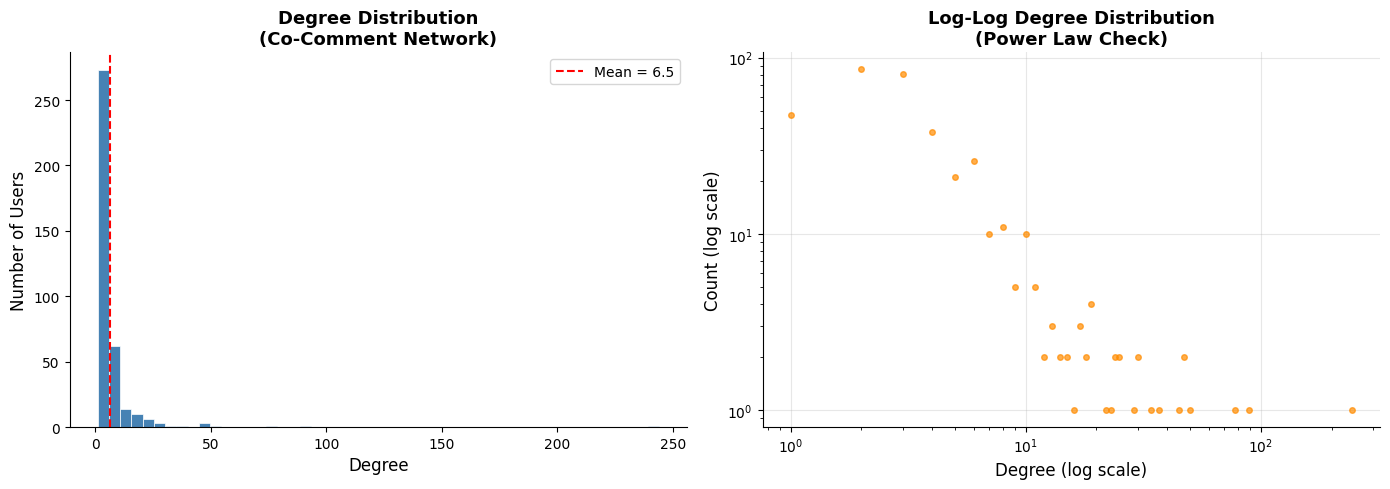

Saved: data/fig_degree_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Degree distribution histogram ─────────────────────────────────────────────
ax = axes[0]
ax.hist(degrees, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Degree', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Degree Distribution\n(Co-Comment Network)', fontsize=13, fontweight='bold')
ax.axvline(avg_degree, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {avg_degree:.1f}')
ax.legend()

# ── Log-log degree distribution (power law check) ─────────────────────────────
ax2 = axes[1]
degree_counts = Counter(degrees)
x = sorted(degree_counts.keys())
y = [degree_counts[d] for d in x]

ax2.loglog(x, y, 'o', markersize=4, color='darkorange', alpha=0.7)
ax2.set_xlabel('Degree (log scale)', fontsize=12)
ax2.set_ylabel('Count (log scale)', fontsize=12)
ax2.set_title('Log-Log Degree Distribution\n(Power Law Check)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/fig_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_degree_distribution.png")

## Cell 11 — Visualisation 2: Centrality Distributions

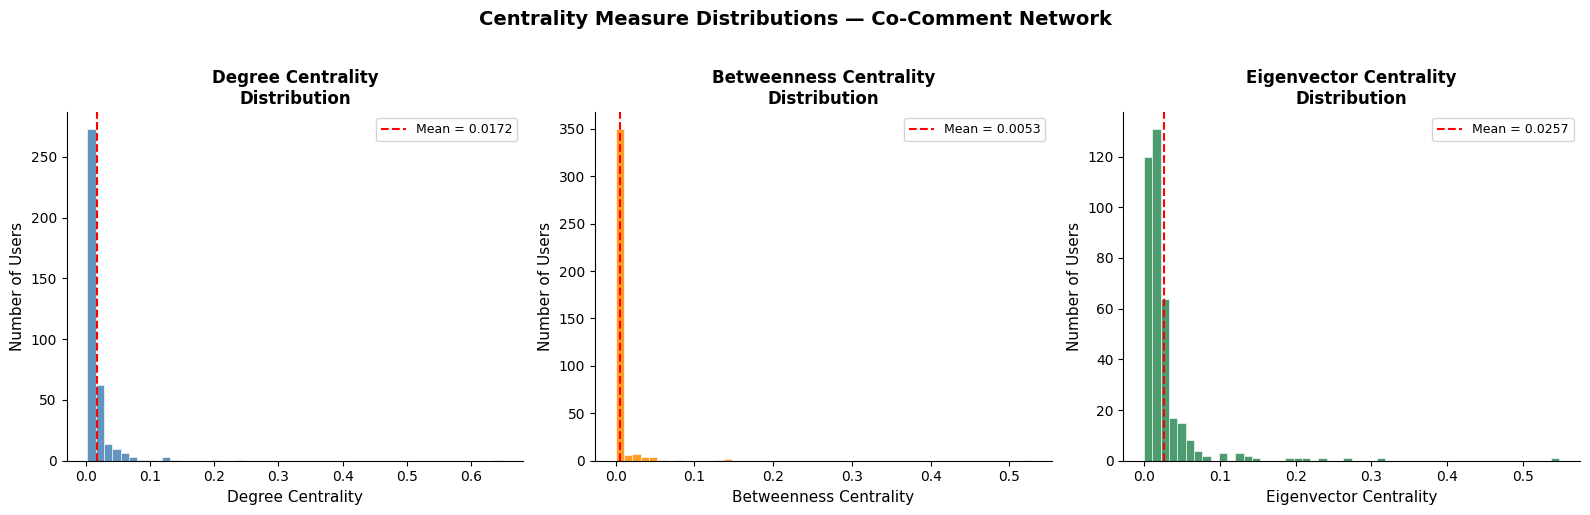

Saved: data/fig_centrality_distributions.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('degree_centrality', 'Degree Centrality', 'steelblue'),
    ('betweenness_centrality', 'Betweenness Centrality', 'darkorange'),
    ('eigenvector_centrality', 'Eigenvector Centrality', 'seagreen'),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = node_features[col].dropna()
    ax.hist(data, bins=50, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Number of Users', fontsize=11)
    ax.set_title(f'{label}\nDistribution', fontsize=12, fontweight='bold')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {data.mean():.4f}')
    ax.legend(fontsize=9)

plt.suptitle('Centrality Measure Distributions — Co-Comment Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_centrality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_centrality_distributions.png")

## Cell 12 — Visualisation 3: Community Size Distribution

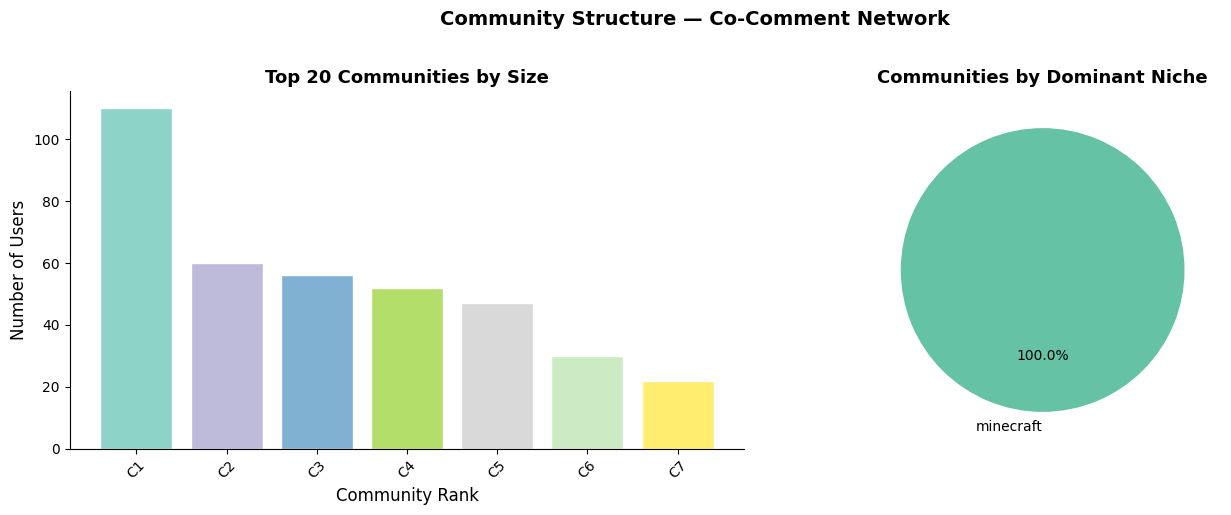

Saved: data/fig_community_structure.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Community sizes bar chart (top 20) ───────────────────────────────────────
ax = axes[0]
top20 = community_profile.head(20)
colors = plt.cm.Set3(np.linspace(0, 1, len(top20)))
bars = ax.bar(range(len(top20)), top20['size'], color=colors, edgecolor='white')
ax.set_xlabel('Community Rank', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Top 20 Communities by Size', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(top20)))
ax.set_xticklabels([f'C{i+1}' for i in range(len(top20))], rotation=45)

# ── Community niche breakdown ─────────────────────────────────────────────────
ax2 = axes[1]
niche_counts = community_profile['dominant_niche'].value_counts()
ax2.pie(niche_counts.values, labels=niche_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(niche_counts)), startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Communities by Dominant Niche', fontsize=13, fontweight='bold')

plt.suptitle('Community Structure — Co-Comment Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_community_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_community_structure.png")

## Cell 13 — Visualisation 4: Centrality vs Virality Tier

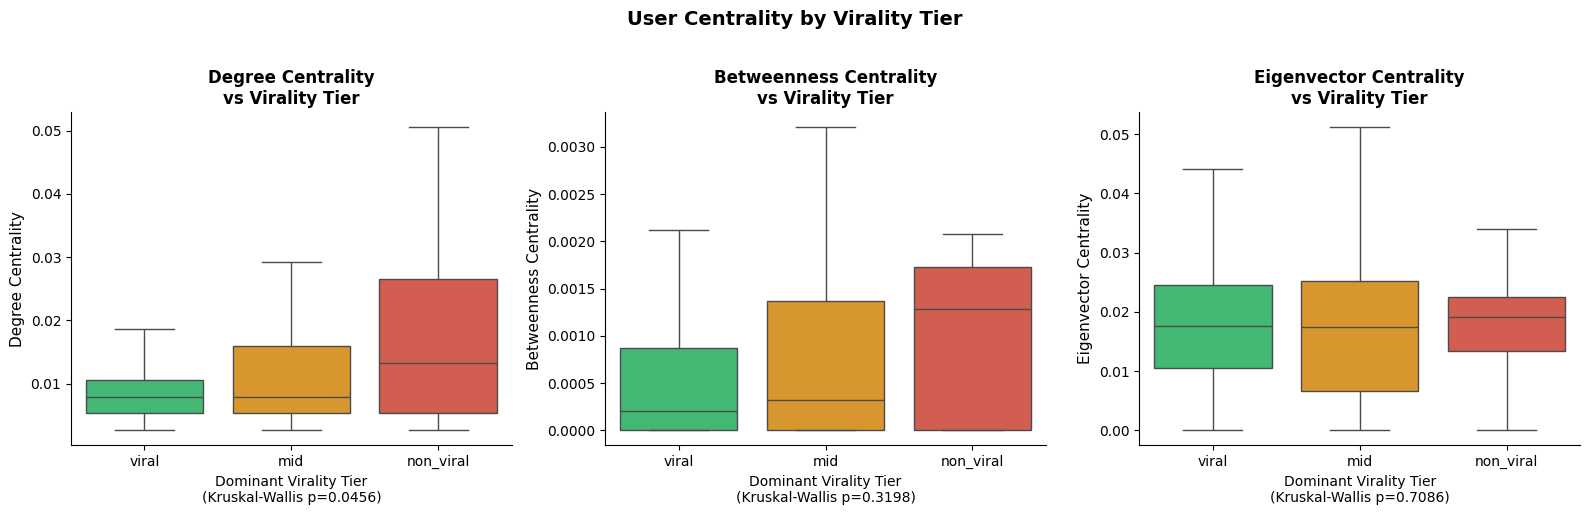

Saved: data/fig_centrality_vs_virality.png


In [13]:
# ── Compare centrality of users who mostly comment on viral vs non-viral videos
tier_order = ['viral', 'mid', 'non_viral']
palette = {'viral': '#2ecc71', 'mid': '#f39c12', 'non_viral': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['degree_centrality', 'betweenness_centrality', 'eigenvector_centrality']):
    plot_data = node_features[node_features['dominant_tier'].isin(tier_order)]
    sns.boxplot(
        data=plot_data, x='dominant_tier', y=metric,
        order=tier_order, palette=palette, ax=ax,
        showfliers=False  # Hide outliers for cleaner plot
    )
    ax.set_xlabel('Dominant Virality Tier', fontsize=11)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_title(f'{metric.replace("_", " ").title()}\nvs Virality Tier', fontsize=12, fontweight='bold')

    # Statistical test: Kruskal-Wallis (non-parametric ANOVA)
    groups = [plot_data[plot_data['dominant_tier'] == t][metric].dropna() for t in tier_order]
    if all(len(g) > 0 for g in groups):
        stat, p = stats.kruskal(*groups)
        ax.set_xlabel(f'Dominant Virality Tier\n(Kruskal-Wallis p={p:.4f})', fontsize=10)

plt.suptitle('User Centrality by Virality Tier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_centrality_vs_virality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_centrality_vs_virality.png")

## Cell 14 — Visualisation 5: Network Graph (Spring Layout)

Computing spring layout (may take a moment)...


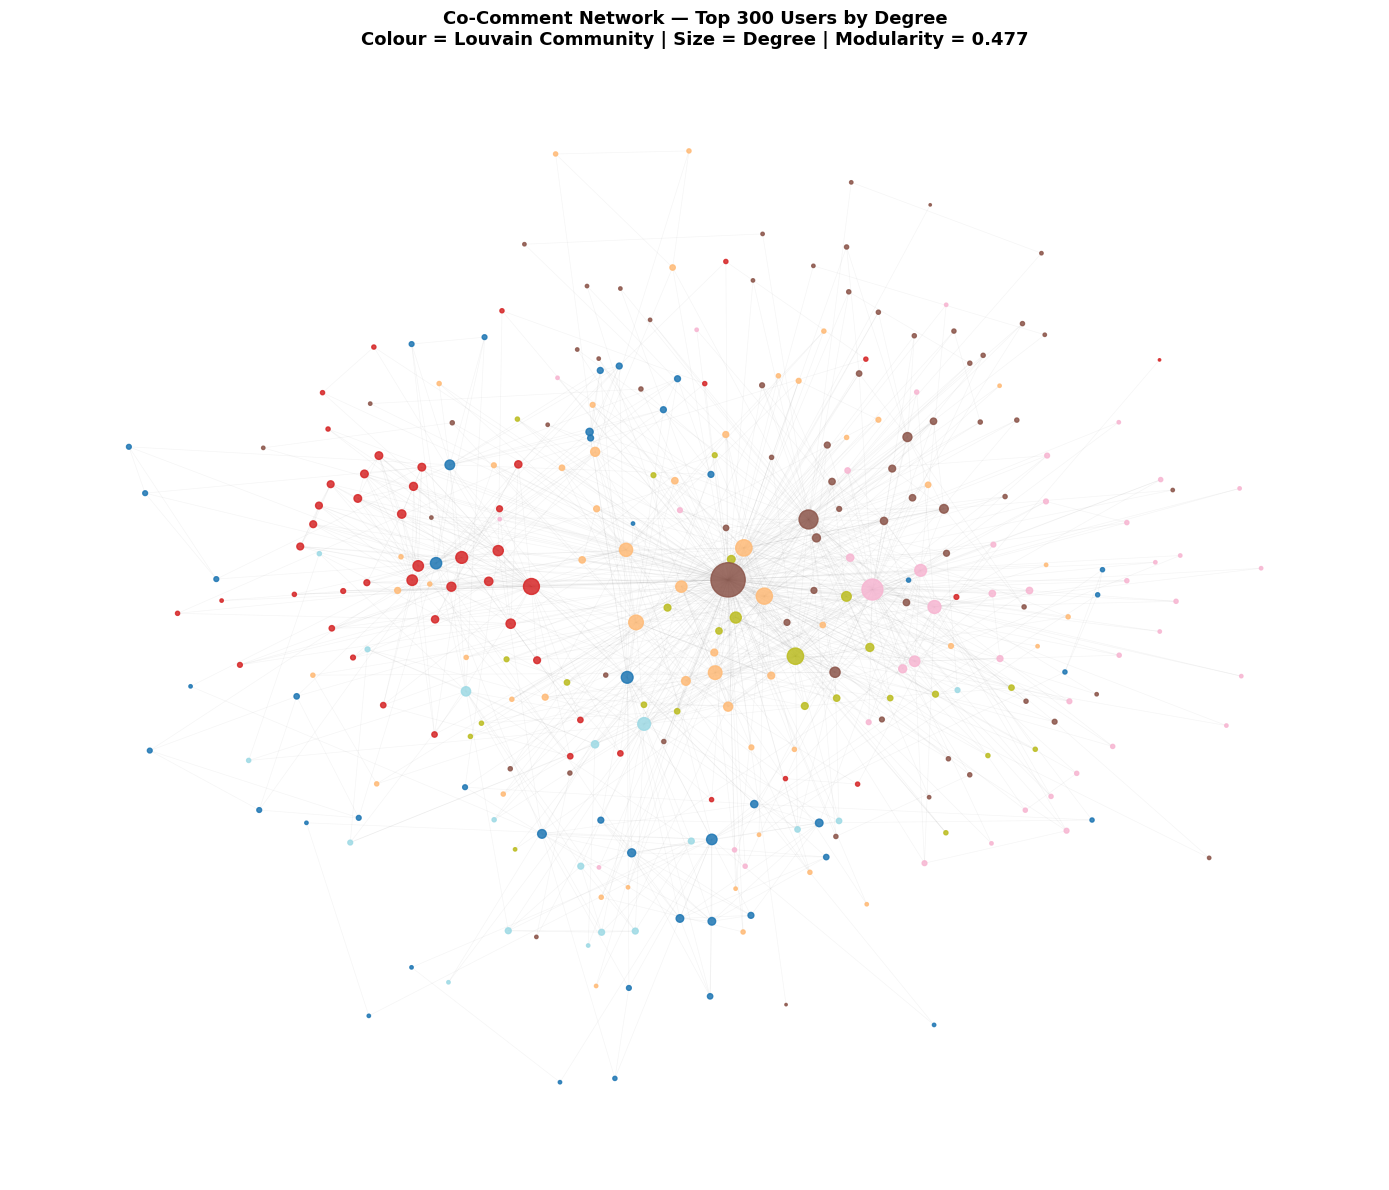

Saved: data/fig_network_graph.png


In [14]:
# ── Visualise a subgraph for readability ──────────────────────────────────────
# Use top 300 nodes by degree for a clean, readable visualisation
top_nodes = node_features.nlargest(300, 'degree')['user_id'].tolist()
G_sub = G_co.subgraph(top_nodes).copy()

# Community colours for subgraph nodes
sub_communities = [partition.get(n, 0) for n in G_sub.nodes()]
unique_comms = list(set(sub_communities))
cmap = plt.cm.get_cmap('tab20', len(unique_comms))
comm_color = {c: cmap(i) for i, c in enumerate(unique_comms)}
node_colors = [comm_color[c] for c in sub_communities]

# Node size = degree
node_sizes = [G_sub.degree(n) * 3 for n in G_sub.nodes()]

# Layout
print("Computing spring layout (may take a moment)...")
pos = nx.spring_layout(G_sub, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G_sub, pos, alpha=0.08, width=0.5, edge_color='grey', ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.85, ax=ax)

ax.set_title(
    f'Co-Comment Network — Top 300 Users by Degree\n'
    f'Colour = Louvain Community | Size = Degree | Modularity = {modularity:.3f}',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('data/fig_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_network_graph.png")

## Cell 15 — Save Graphs & Final Summary

In [15]:
# ── Save graphs in GEXF format (readable by Gephi if needed) ─────────────────
nx.write_gexf(G_co, 'data/co_comment_graph.gexf')
nx.write_gexf(G_reply, 'data/reply_graph.gexf')

print("\n" + "="*60)
print("NETWORK ANALYSIS COMPLETE")
print("="*60)

print(f"""
Co-Comment Network:
  Nodes:                 {G_co.number_of_nodes():,}
  Edges:                 {G_co.number_of_edges():,}
  Density:               {nx.density(G_co):.6f}
  Avg clustering coeff:  {avg_clustering:.4f}
  Communities found:     {n_communities}
  Modularity:            {modularity:.4f}

Reply Network:
  Nodes:                 {G_reply.number_of_nodes():,}
  Edges:                 {G_reply.number_of_edges():,}

Files saved:
  data/co_comment_graph.gexf
  data/reply_graph.gexf
  data/node_features.csv
  data/community_profiles.csv
  data/fig_degree_distribution.png
  data/fig_centrality_distributions.png
  data/fig_community_structure.png
  data/fig_centrality_vs_virality.png
  data/fig_network_graph.png
""")


NETWORK ANALYSIS COMPLETE

Co-Comment Network:
  Nodes:                 377
  Edges:                 1,218
  Density:               0.017185
  Avg clustering coeff:  0.1074
  Communities found:     7
  Modularity:            0.4766

Reply Network:
  Nodes:                 18,267
  Edges:                 15,277

Files saved:
  data/co_comment_graph.gexf
  data/reply_graph.gexf
  data/node_features.csv
  data/community_profiles.csv
  data/fig_degree_distribution.png
  data/fig_centrality_distributions.png
  data/fig_community_structure.png
  data/fig_centrality_vs_virality.png
  data/fig_network_graph.png

